# Linear Regression: 
You are given a CSV file that contains penguins data: **species, island, bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g, sex**. 

Design ML model that can make prediction on **species** based on **bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g** .


Steps:

```
--> Collect data
--> Split into training + testing
--> Feed training data to model (i.e. train the model)
--> Evaluate the model by feeding testing data
```


## Collect the data

In [9]:
import pandas as pd

df = pd.read_csv('data_penguins.csv')
print(df)

     Unnamed: 0 species     island  bill_length_mm  bill_depth_mm  \
0             0  Adelie  Torgersen            39.1           18.7   
1             1  Adelie  Torgersen            39.5           17.4   
2             2  Adelie  Torgersen            40.3           18.0   
3             3  Adelie  Torgersen             NaN            NaN   
4             4  Adelie  Torgersen            36.7           19.3   
..          ...     ...        ...             ...            ...   
339         339  Gentoo     Biscoe             NaN            NaN   
340         340  Gentoo     Biscoe            46.8           14.3   
341         341  Gentoo     Biscoe            50.4           15.7   
342         342  Gentoo     Biscoe            45.2           14.8   
343         343  Gentoo     Biscoe            49.9           16.1   

     flipper_length_mm  body_mass_g     sex  
0                181.0       3750.0    Male  
1                186.0       3800.0  Female  
2                195.0       3250

In [10]:
# Seperate your data into feature X and response y
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

X = df[features]  # This is the feature that would predict the y
y = df["species"] # This is th prediction: labels/response/target

In [15]:
# value counts of species
print(y.value_counts())

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


## Now we split the dataset into training / testing

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2)

In [12]:
# Lets see how many records are in training and testing dataset
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (275, 4)
X_test shape: (69, 4)


## Feed training data to the model (i.e. train the model)

In [13]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

# This can take long time depending on size of training data
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [14]:
# Lets make a prediction on a penguin and check against the actual value. 
# I picked the data at idx=340 and actual species=Gentoo
# bill_length_mm=46.8,  bill_depth_mm=14.3, flipper_length_mm=215, body_mass_g=4850

X_sample = [[46.8, 14.3, 215.0, 4850.0 ],] # data for Gentoo

X_df = pd.DataFrame(X_sample, columns=X_train.columns)

prediction = model.predict(X_df)

print("The prediction is", prediction)

The prediction is ['Gentoo']


##  Evaluate the model by feeding the testing data

In [16]:
# Predict on test data
y_pred = model.predict(X_test)
print(y_pred)

['Gentoo' 'Gentoo' 'Gentoo' 'Adelie' 'Adelie' 'Chinstrap' 'Adelie'
 'Chinstrap' 'Chinstrap' 'Gentoo' 'Adelie' 'Gentoo' 'Gentoo' 'Chinstrap'
 'Gentoo' 'Gentoo' 'Gentoo' 'Gentoo' 'Adelie' 'Chinstrap' 'Gentoo'
 'Gentoo' 'Adelie' 'Gentoo' 'Gentoo' 'Gentoo' 'Gentoo' 'Gentoo' 'Gentoo'
 'Gentoo' 'Gentoo' 'Gentoo' 'Adelie' 'Adelie' 'Chinstrap' 'Gentoo'
 'Adelie' 'Gentoo' 'Adelie' 'Gentoo' 'Chinstrap' 'Gentoo' 'Chinstrap'
 'Gentoo' 'Gentoo' 'Gentoo' 'Gentoo' 'Gentoo' 'Gentoo' 'Gentoo' 'Adelie'
 'Gentoo' 'Adelie' 'Gentoo' 'Gentoo' 'Adelie' 'Chinstrap' 'Adelie'
 'Adelie' 'Adelie' 'Gentoo' 'Gentoo' 'Gentoo' 'Adelie' 'Adelie' 'Gentoo'
 'Gentoo' 'Gentoo' 'Chinstrap']


In [17]:
# lets check the prediction on first 5 data points of X_test
print(X_test[:5])
print(y_pred[:5])

     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
243            46.3           15.8              215.0       5050.0
322            47.2           15.5              215.0       4975.0
277            45.5           15.0              220.0       5000.0
123            41.4           18.5              202.0       3875.0
54             34.5           18.1              187.0       2900.0
['Gentoo' 'Gentoo' 'Gentoo' 'Adelie' 'Adelie']


In [19]:
# Lets compare the predicted vs actual value on test data
print("actual :", y_test[:5].values)
print("predict:", y_pred[:5])

actual : ['Gentoo' 'Gentoo' 'Gentoo' 'Adelie' 'Adelie']
predict: ['Gentoo' 'Gentoo' 'Gentoo' 'Adelie' 'Adelie']


In [20]:
# accuracy score
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7246376811594203


# OPTIONAL

In [21]:
# Check misclassified labels using confusion_matrix 

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[14  4  9]
 [ 4  6  2]
 [ 0  0 30]]


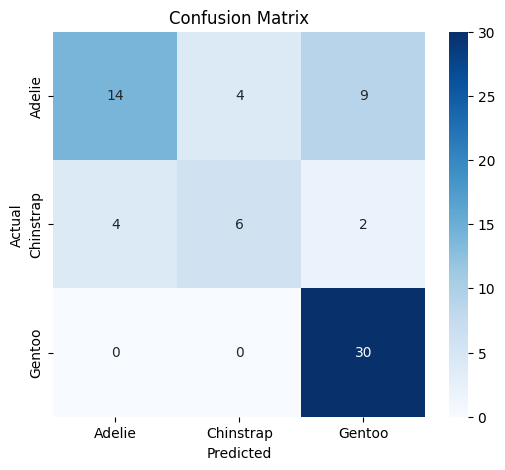

In [22]:
# Plot confusion matrix heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()